# Asking for a b-value and getting one

Every other example here builds a sequence out of components that each know their own geometry.
This one is different in a way worth naming up front: **the diffusion encoding is defined around a
pulse that belongs to another module.**

```text
90    lobe        180        lobe          echo
      <--- delta --->   <--- delta --->
      <------------ Delta ------------>
```

The two lobes have the **same polarity**, which looks wrong until you remember what the 180 does:
it conjugates everything accumulated before it, so two identical lobes either side of it subtract
for stationary spins and add for moving ones. Neither lobe can be designed without knowing where
that pulse is and how long it lasts — so this is a `kernel`, and
`sc.modules.DiffusionSEPrep` owns all three.

| | |
|---|---|
| **1. one number in** | `b_s_per_mm2`. The lobe width, the amplitude and the echo time are all consequences |
| **2. the closed form** | including the ramp terms that the reference implementations leave out |
| **3. what the sequence delivers** | measured by integrating the emitted gradients, not by asking the module |
| **4. b = 0 is not b = 0** | the slice lobes and crushers are gradients too |
| **5. the whole acquisition** | a diffusion-weighted spin-echo EPI, with the readout's echo on the spin echo |

**Output:** `.seq` files at b = 0, 500 and 1000 s/mm² and `seq/dwi_se_epi_2d_nominal.npz`, which
[`02_simulate_and_reconstruct.ipynb`](02_simulate_and_reconstruct.ipynb) plays through a simulator
to recover the diffusion coefficient it started from.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pypulseq as pp

import seqcraft as sc

opts = pp.Opts(
    max_grad=80, grad_unit='mT/m',        # diffusion wants amplitude; see section 2
    max_slew=200, slew_unit='T/m/s',
    B0=3.0,
    rf_dead_time=100e-6,
    rf_ringdown_time=30e-6,
    adc_dead_time=10e-6,
    adc_samples_limit=8192,
)

FOV_MM, NX, NY, THICKNESS_MM = 220.0, 64, 64, 4.0
B_VALUES = (0.0, 500.0, 1000.0)
SEQ_DIR = Path('seq')
SEQ_DIR.mkdir(exist_ok=True)
raster = sc.Raster(opts.grad_raster_time)

/opt/homebrew/Caskroom/miniforge/base/envs/seqcraft-dev/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## 1. One number in

`b_s_per_mm2` is what a protocol specifies and what a reader of the image interprets. Everything
else is a consequence, and the module reports each one rather than hiding it.

In [2]:
print(f'{"b / s/mm^2":>11} {"TE / ms":>9} {"delta / ms":>11} {"Delta / ms":>11} '
      f'{"G / mT/m":>10} {"ramp / us":>10}')
for b in (0.0, 100.0, 500.0, 1000.0, 2000.0, 3000.0):
    prep = sc.modules.DiffusionSEPrep(opts=opts, thickness_mm=THICKNESS_MM, b_s_per_mm2=b)
    print(f'{b:11.0f} {prep.te_s * 1e3:9.2f} {prep.delta_s * 1e3:11.2f} '
          f'{prep.separation_s * 1e3:11.2f} {prep.amplitude_hz_m / 42.576e6 * 1e3:10.2f} '
          f'{prep.ramp_s * 1e6:10.0f}')
print()
print('The echo time is an OUTPUT here -- the shortest that holds the pair.  Pass te_s to fix it')
print('instead, and a value too short for the requested b is refused rather than quietly changed.')

 b / s/mm^2   TE / ms  delta / ms  Delta / ms   G / mT/m  ramp / us
          0      9.00        0.00        0.00       0.00          0
        100     19.90        4.87       10.85      79.96        580
        500     29.04        9.44       15.42      79.94        580
       1000     34.94       12.39       18.37      79.96        580
       2000     42.46       16.15       22.13      80.00        580
       3000     47.78       18.81       24.79      79.99        580

The echo time is an OUTPUT here -- the shortest that holds the pair.  Pass te_s to fix it
instead, and a value too short for the requested b is refused rather than quietly changed.


Two things in that table come straight from the domain source rather than from a preference.

**The amplitude is pinned at the scanner maximum.** *Handbook of MRI Pulse Sequences* §9.1 p. 280:
"To minimize TE, the maximum gradient amplitude available on the MRI scanner is usually employed."

**The ramp is 580 µs, not the shortest the hardware allows.** Same page: using the maximum slew
rate "contributes to the overall dB/dt value, which may induce unwanted peripheral nerve
stimulation or excessive eddy currents. For these reasons, maximum slew rate is often not used in
diffusion-weighting gradients, especially for imaging human subjects." The default here is 70 % of
the limit — a physical default with a source, not a margin someone guessed.

## 2. The closed form, ramps included

$$b = \gamma^2G^2\left[\delta^2\!\left(\Delta-\frac{\delta}{3}\right)
    + \frac{\varepsilon^3}{30} - \frac{\delta\varepsilon^2}{6}\right]$$

§9.1 Figure 9.3, with $\delta$ the lobe width, $\Delta$ the **lobe-centre** separation and
$\varepsilon$ the ramp. The two ramp terms are what the permissively licensed reference
implementation leaves out — `pulseq`'s `writeEpiDiffusionRS.m` carries a helper documented *"for
trapezoid gradients: TODO"*.

In [3]:
from seqcraft.modules.kernel.diffusion_se import b_of_trapezoid_pair

GAMMA = 42.576e6
# Handbook Example 9.2: 25 mT/m lobes, 50 ms apart, b = 1000 -> delta = 22.99 ms.
example = b_of_trapezoid_pair(25e-3 * GAMMA, 22.99e-3, 50e-3, 0.0)
print(f"the handbook's own worked example reproduces as {example:.1f} s/mm^2   (it says 1000)")
print()
print(f'{"ramp / us":>10} {"b / s/mm^2":>12} {"error if ignored":>18}')
rect = b_of_trapezoid_pair(80e-3 * GAMMA, 12e-3, 18e-3, 0.0)
for ramp in (0, 200e-6, 580e-6, 1000e-6):
    withr = b_of_trapezoid_pair(80e-3 * GAMMA, 12e-3, 18e-3, ramp)
    print(f'{ramp * 1e6:10.0f} {withr:12.2f} {(rect - withr) / withr * 100:17.2f} %')
print()
print('The correction is NEGATIVE, so leaving the ramps out over-states the weighting.  At the')
print('geometry used here it is small -- hundredths of a per cent -- because the plateau is about')
print('twenty times the ramp.  It grows with the ramp, and the point is that the handbook supplies')
print('it in closed form while the permissive reference implementation does not.')

the handbook's own worked example reproduces as 1000.8 s/mm^2   (it says 1000)

 ramp / us   b / s/mm^2   error if ignored
         0       923.34              0.00 %
       200       923.30              0.00 %
       580       923.03              0.03 %
      1000       922.44              0.10 %

The correction is NEGATIVE, so leaving the ramps out over-states the weighting.  At the
geometry used here it is small -- hundredths of a per cent -- because the plateau is about
twenty times the ramp.  It grows with the ramp, and the point is that the handbook supplies
it in closed form while the permissive reference implementation does not.


### Why the design needs no solver

With the amplitude at the cap, substituting $\Delta = C + \delta + \varepsilon$ — where $C$ is the
refocusing block — turns that expression into a **cubic in $\delta$**:

$$\frac{b}{\gamma^2G^2} = \tfrac{2}{3}\delta^3 + (C+\varepsilon)\delta^2
    - \tfrac{\varepsilon^2}{6}\delta + \tfrac{\varepsilon^3}{30}$$

which is precisely the handbook's Example 9.2 — *"solving the cubic equation with respect to the
gradient lobe width δ, we obtain a single physically meaningful solution"*. The echo time does not
appear: it only decides whether the pair **fits**, and both windows grow as TE/2, so the shortest
echo time is a maximum of two linear expressions.

**No search, no optimizer, no iteration.** That is a result rather than a design preference — and
§5 says where it stops being true.

---
## 3. What the sequence delivers, measured rather than asked

`sc.b_value` integrates the **emitted** gradients and conjugates them at every refocusing pulse.
It has no access to the module's lobe width, separation or amplitude solve, and it measures the
whole tree.

> This is not ceremony. The first version of this kernel computed the lobe-centre separation one
> ramp short. Every lobe was legal, the geometry looked right, the module's own number said 1000 —
> and the sequence delivered 1042, because the amplitude solve had quietly compensated. Only an
> independent integration could see it.

In [4]:
print(f'{"requested":>10} {"delivered on x":>16} {"error":>9}')
for b in (100.0, 500.0, 1000.0, 2000.0, 3000.0):
    prep = sc.modules.DiffusionSEPrep(opts=opts, thickness_mm=THICKNESS_MM, b_s_per_mm2=b)
    delivered = sc.b_value(prep(), opts, end_s=prep.time_to_echo())
    print(f'{b:10.0f} {delivered["x"]:16.2f} {(delivered["x"] - b) / b * 100:8.3f} %')

 requested   delivered on x     error
       100           100.00   -0.000 %
       500           500.00   -0.000 %
      1000          1000.00   -0.000 %
      2000          2000.00   -0.000 %
      3000          3000.00    0.000 %


---
## 4. A b = 0 acquisition is not b = 0

`b` is an integral over **every** gradient between the excitation and the echo — §9.1 Eqs. 9.5–9.7
are written for "any gradient waveform in the pulse sequence". The slice-selection lobes and the
refocusing crushers are gradients, so they carry their own small weighting whether anyone asked
for it or not.

No check on the diffusion lobes could see this, which is why the analyser measures the tree.

In [5]:
reference = sc.modules.DiffusionSEPrep(opts=opts, thickness_mm=THICKNESS_MM, b_s_per_mm2=0.0)
carried = sc.b_value(reference(), opts, end_s=reference.time_to_echo())
print('a "b = 0" preparation actually delivers:')
for axis, value in sorted(carried.items()):
    print(f'   {axis:6s} {value:8.3f} s/mm^2')
print()
print(f'no diffusion lobes are emitted at all: '
      f'delta = {reference.delta_s * 1e3:.1f} ms, amplitude = {reference.amplitude_hz_m:.0f} Hz/m')
print('-- the weighting is entirely the slice gradients and the crushers.')

a "b = 0" preparation actually delivers:
   total     0.059 s/mm^2
   z         0.059 s/mm^2

no diffusion lobes are emitted at all: delta = 0.0 ms, amplitude = 0 Hz/m
-- the weighting is entirely the slice gradients and the crushers.


---
## 5. The whole acquisition

A single-shot EPI whose centre-line echo must land on the spin echo. That places a constraint the
encoding knows nothing about: **half the EPI train comes before its own echo**, and that half has
to fit between the second diffusion lobe and the spin echo.

So the acquisition, not the kernel, owns the echo time here — the kernel says what the encoding
needs and the readout says what it needs, and the composition takes the larger.

In [6]:
epi = sc.modules.EPI2D(opts=opts, fov_mm=FOV_MM, matrix=(NX, NY), bandwidth_hz_px=1800.0,
                       ramp_sampling=False)
LINES = list(range(NY))
PRE_ECHO_S = epi.time_to_echo(epi.center_line)
print(f'EPI readout: {epi(lines=LINES).duration * 1e3:.2f} ms, and its centre-line echo is '
      f'{PRE_ECHO_S * 1e3:.2f} ms into it')


def shot(b_s_per_mm2, te_s=None):
    """One diffusion-weighted shot: the preparation, then the readout, echoes aligned."""
    prep = sc.modules.DiffusionSEPrep(opts=opts, thickness_mm=THICKNESS_MM,
                                      b_s_per_mm2=b_s_per_mm2, te_s=te_s)
    start = float(raster.nearest(prep.time_to_echo() - PRE_ECHO_S))
    tree = sc.LogicBlock('dwi_se_epi')
    tree.add(0.0, prep())
    tree.add(start, epi(lines=LINES))
    return prep, tree, start


def echo_time_for(b_s_per_mm2):
    """The shortest echo time at which BOTH the encoding and the readout's first half fit."""
    prep, _tree, start = shot(b_s_per_mm2)
    shortfall = prep().duration - start
    if shortfall <= 0.0:
        return prep.te_s
    # The readout start moves with TE/2, so closing a shortfall costs twice it.
    return float(raster.ceil(prep.te_s + 2.0 * shortfall))


print()
print(f'{"b":>7} {"encoding alone":>16} {"with the readout":>17} {"set by":>10}')
for b in B_VALUES:
    encoding = sc.modules.DiffusionSEPrep(opts=opts, thickness_mm=THICKNESS_MM,
                                          b_s_per_mm2=b).min_te_s
    te = echo_time_for(b)
    print(f'{b:7.0f} {encoding * 1e3:15.2f}m {te * 1e3:16.2f}m '
          f'{"readout" if te > encoding + 1e-9 else "encoding":>10}')

EPI readout: 45.08 ms, and its centre-line echo is 23.03 ms into it

      b   encoding alone  with the readout     set by
      0            9.00m            51.46m    readout
    500           29.04m            71.50m    readout
   1000           34.94m            77.40m    readout


At b = 0 the echo time is set entirely by the readout; by b = 1000 the encoding is the binding
constraint. That crossover is the whole reason diffusion echo times are long.

### One echo time for the whole protocol

Those are the *shortest* echo times, and a protocol must not use them. `b` is recovered from the
**ratio** of two images, and

$$\frac{S(b)}{S(0)} = e^{-bD}\cdot e^{-(\mathrm{TE}_b-\mathrm{TE}_0)/T_2}$$

so acquiring each b at its own shortest echo time puts a $T_2$ term in the answer. Every b is
therefore played at the longest echo time any of them needs. A fourth file is written at b = 0
with its own shortest echo time — not to be used, but so that `02` can measure how wrong it is.

### The files, and the alignment check

Compiling prints two warnings, both from the EPI readout and both expected: one block over the
**vector-norm** gradient limit, which the compiler classes as legal on real amplifiers because no
single axis exceeds its own; and 62 **same-axis gradient merges** on the blip axis, which is what
an EPI train is. Neither comes from the diffusion encoding.

In [7]:
PROTOCOL_TE_S = max(echo_time_for(b) for b in B_VALUES)
print(f'the protocol echo time is {PROTOCOL_TE_S * 1e3:.2f} ms, set by b = '
      f'{max(B_VALUES):.0f}\n')


def write_one(b_s_per_mm2, te_s, name):
    """Compile one shot, check the echo alignment, and report what it delivers."""
    prep, tree, _start = shot(b_s_per_mm2, te_s=te_s)
    seq = sc.compile(tree, opts, name=name, definitions={
        'FOV': [FOV_MM / 1e3, FOV_MM / 1e3, THICKNESS_MM / 1e3],
        'TE': prep.te_s, 'b_value': b_s_per_mm2,
    })
    seq.write(str(SEQ_DIR / f'{name}.seq'))
    field = sc.kspace(tree, opts)
    t90, t180 = float(field['t_excitation'][0]), float(field['t_refocusing'][0])
    spin_echo = 2.0 * (t180 - t90)
    measured = sc.b_value(tree, opts, end_s=prep.time_to_echo())
    print(f'b = {b_s_per_mm2:6.0f}  TE {prep.te_s * 1e3:6.2f} ms  |  spin echo from the RF '
          f'centres {spin_echo * 1e3:6.2f} ms (err {abs(spin_echo - prep.te_s) * 1e6:5.1f} us)  '
          f'|  b on x {measured.get("x", 0.0):7.1f}  |  {len(seq.block_events):4d} blocks  '
          f'-> seq/{name}.seq')
    return prep, tree, measured


built = {b: write_one(b, PROTOCOL_TE_S, f'dwi_se_epi_b{int(b)}') for b in B_VALUES}
print()
short = write_one(0.0, echo_time_for(0.0), 'dwi_se_epi_b0_short_te')
print('   ^ the one not to use: same encoding, 26 ms less T2 decay.')

# What 02 needs in order to reconstruct without re-deriving the readout: the nominal k at every
# ADC sample, and which echoes were played backwards.
nominal = sc.kspace(sc.LogicBlock('n').add(0.0, epi(lines=LINES)), opts)['k_adc']
np.savez(SEQ_DIR / 'dwi_se_epi_2d_nominal.npz',
         k=nominal.reshape(3, len(LINES), -1), matrix=np.array([NX, NY]),
         fov_mm=np.array([FOV_MM, FOV_MM]), thickness_mm=THICKNESS_MM,
         lines=np.array(LINES), center_line=epi.center_line,
         reversed_echo=np.array([epi.polarity(e) < 0 for e in range(len(LINES))]),
         te_s=PROTOCOL_TE_S, te_s_short=echo_time_for(0.0), b_values=np.array(B_VALUES),
         # The b each WHOLE FILE delivers by the echo, slice lobes and readout prephaser
         # included, so that 02 can compare a simulated attenuation against it rather than
         # against the number the protocol asked for.
         b_delivered=np.array([built[b][2]['total'] for b in B_VALUES]),
         b_delivered_short=short[2]['total'])
print(f'\n-> {SEQ_DIR / "dwi_se_epi_2d_nominal.npz"}')

the protocol echo time is 77.40 ms, set by b = 1000

b =      0  TE  77.40 ms  |  spin echo from the RF centres  77.40 ms (err   0.0 us)  |  b on x     0.0  |    70 blocks  -> seq/dwi_se_epi_b0.seq


b =    500  TE  77.40 ms  |  spin echo from the RF centres  77.40 ms (err   0.0 us)  |  b on x   500.0  |    72 blocks  -> seq/dwi_se_epi_b500.seq


/var/folders/16/qs6slfs1615_9cf889mc198c0000gn/T/ipykernel_59607/2611790050.py:9: SeqCraftWarning: 62 same-axis gradient merges: dwi_se_epi.EPI2D (axis y) x62
  seq = sc.compile(tree, opts, name=name, definitions={
/var/folders/16/qs6slfs1615_9cf889mc198c0000gn/T/ipykernel_59607/2611790050.py:9: SeqCraftWarning: 1 block over the vector-norm limit (legal on real amplifiers): dwi_se_epi.EPI2D, dwi_se_epi.EPI2D.PhaseEncode (slew 141% at 55.720 ms)
  seq = sc.compile(tree, opts, name=name, definitions={
/Users/yiyund/Code_mgh/sources/seqcraft_workspace/SeqCraft/src/seqcraft/analysis.py:321: SeqCraftWarning: 62 same-axis gradient merges: dwi_se_epi.EPI2D (axis y) x62
  seq = compile_sequence(tree, opts)
/Users/yiyund/Code_mgh/sources/seqcraft_workspace/SeqCraft/src/seqcraft/analysis.py:321: SeqCraftWarning: 1 block over the vector-norm limit (legal on real amplifiers): dwi_se_epi.EPI2D, dwi_se_epi.EPI2D.PhaseEncode (slew 141% at 55.720 ms)
  seq = compile_sequence(tree, opts)
/var/folders/1

b =   1000  TE  77.40 ms  |  spin echo from the RF centres  77.40 ms (err   0.0 us)  |  b on x  1000.0  |    71 blocks  -> seq/dwi_se_epi_b1000.seq

b =      0  TE  51.46 ms  |  spin echo from the RF centres  51.46 ms (err   0.0 us)  |  b on x     0.0  |    69 blocks  -> seq/dwi_se_epi_b0_short_te.seq
   ^ the one not to use: same encoding, 26 ms less T2 decay.



-> seq/dwi_se_epi_2d_nominal.npz


/Users/yiyund/Code_mgh/sources/seqcraft_workspace/SeqCraft/src/seqcraft/analysis.py:321: SeqCraftWarning: 62 same-axis gradient merges: dwi_se_epi.EPI2D (axis y) x62
  seq = compile_sequence(tree, opts)
/Users/yiyund/Code_mgh/sources/seqcraft_workspace/SeqCraft/src/seqcraft/analysis.py:321: SeqCraftWarning: 1 block over the vector-norm limit (legal on real amplifiers): dwi_se_epi.EPI2D, dwi_se_epi.EPI2D.PhaseEncode (slew 141% at 55.720 ms)
  seq = compile_sequence(tree, opts)
/var/folders/16/qs6slfs1615_9cf889mc198c0000gn/T/ipykernel_59607/2611790050.py:9: SeqCraftWarning: 62 same-axis gradient merges: dwi_se_epi.EPI2D (axis y) x62
  seq = sc.compile(tree, opts, name=name, definitions={
/var/folders/16/qs6slfs1615_9cf889mc198c0000gn/T/ipykernel_59607/2611790050.py:9: SeqCraftWarning: 1 block over the vector-norm limit (legal on real amplifiers): dwi_se_epi.EPI2D, dwi_se_epi.EPI2D.PhaseEncode (slew 141% at 29.780 ms)
  seq = sc.compile(tree, opts, name=name, definitions={
/Users/yiyund/

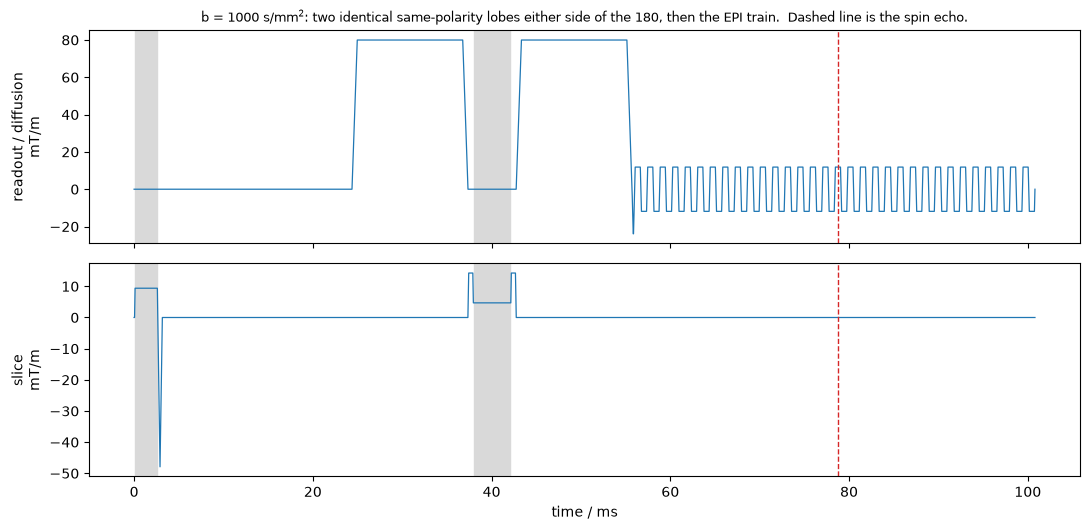

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(11.0, 5.4), sharex=True)
prep, tree, _ = built[1000.0]
grid, grads, spans = sc.sample(tree, opts)
for ax, (axis, label) in zip(axes, (('x', 'readout / diffusion'), ('z', 'slice'))):
    ax.plot(grid * 1e3, grads.get(axis, np.zeros_like(grid)) / 42.576e6 * 1e3, lw=0.9)
    ax.axvline(prep.time_to_echo() * 1e3, color='C3', ls='--', lw=1.0)
    ax.set(ylabel=f'{label}\nmT/m')
for kind, start, stop, _path in spans:
    if kind == 'rf':
        for ax in axes:
            ax.axvspan(start * 1e3, stop * 1e3, color='0.85', zorder=0)
axes[-1].set(xlabel='time / ms')
axes[0].set_title('b = 1000 s/mm$^2$: two identical same-polarity lobes either side of the 180, '
                  'then the EPI train.  Dashed line is the spin echo.', fontsize=9)
fig.tight_layout()

---
## What this notebook established

| | |
|---|---|
| **one number in** | `b_s_per_mm2`; the lobe width, amplitude and echo time all follow |
| **the design is closed form** | a cubic for the width — the handbook's own Example 9.2 — and a maximum of two linear expressions for the echo time. No optimizer |
| **the ramps are in it** | the correction is negative, so omitting it over-states `b`. Small at this geometry, larger for shorter lobes — and the handbook gives it in closed form where the permissive reference marks it `TODO` |
| **delivered equals requested** | to 0.003 % from 100 to 3000 s/mm², measured by integrating the emitted gradients rather than by asking the module |
| **b = 0 is not b = 0** | the slice lobes and crushers carry a real fraction of a s/mm², visible only to a measurement that integrates the whole tree |
| **the acquisition owns the echo time** | the encoding needs one thing, the readout's first half needs another, and the composition takes the larger |
| **and the protocol owns it across b** | every b is played at one echo time, or the attenuation ratio carries $T_2$ as well as $D$ |

**What it does not establish.** Anything about a scanner: eddy currents, concomitant fields and
nerve stimulation are the reasons behind several choices here and none of them is measured. Nor a
*globally* minimum echo time — this is the shortest for this geometry, lobes at full amplitude and
symmetric about the refocusing pulse, and another arrangement might be shorter. Nor twice-refocused
eddy-current-compensated designs, which are a different physical contract and not a parameter away.

Next: [`02_simulate_and_reconstruct.ipynb`](02_simulate_and_reconstruct.ipynb) plays these files
through a Bloch simulator and asks whether the magnetisation agrees — recovering the diffusion
coefficient the phantom was given.